# 🍎 Fruit & Vegetable Rotting Detector
**Pipeline:** YOLOv8 (object detection) → EfficientNet-B2 (freshness classification)

### Handles:
- 🟤 Internal rot (dark cores, browning flesh)
- 🔘 Surface mold (grey/white fuzzy growth)
- 🟡 Standard discoloration rot
- ✅ Fresh produce

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, ConcatDataset, Dataset
from torchvision import transforms, models
from datasets import load_dataset
from ultralytics import YOLO
from PIL import Image
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch.nn.functional as F
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import os
import numpy as np

device = "cuda" if torch.cuda.is_available() else ("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


## 1. Dataset
We combine two datasets to cover mild rot AND severe mold/internal rot:
- `jojogo9/freshness_of_fruits_and_veges_256` — standard freshness
- `Faredhimself/fruit-vegetable-disease-detection` — heavily diseased/moldy produce

In [2]:
raw_dataset = load_dataset("jojogo9/freshness_of_fruits_and_veges_256")
original_labels = raw_dataset['train'].features['label'].names

print(f"Dataset 1 classes: {original_labels}")

target_class_names = [
    'FreshApple', 'RottenApple',
    'FreshBanana', 'RottenBanana',
    'FreshOrange', 'RottenOrange',
]
target_class_names = [c for c in target_class_names if c in original_labels]
target_original_ids = [original_labels.index(name) for name in target_class_names]
id_mapping = {old_id: new_id for new_id, old_id in enumerate(target_original_ids)}

remapped_dataset = raw_dataset.filter(
    lambda ex: ex['label'] in target_original_ids
).map(
    lambda ex: {**ex, 'label': id_mapping[ex['label']]}
)

labels = target_class_names
num_classes = len(labels)
print(f"Using {num_classes} classes: {labels}")
print(f"Dataset 1 train size: {len(remapped_dataset['train'])}")

Dataset 1 classes: ['FreshApple', 'FreshBanana', 'FreshCucumber', 'FreshGrape', 'FreshGuava', 'FreshJujube', 'FreshOkra', 'FreshOrange', 'FreshPomegranate', 'FreshPotato', 'FreshStrawberry', 'FreshTomato', 'RottenApple', 'RottenBanana', 'RottenCucumber', 'RottenGrape', 'RottenGuava', 'RottenJujube', 'RottenOkra', 'RottenOrange', 'RottenPomegranate', 'RottenPotato', 'RottenStrawberry', 'RottenTomato']
Using 6 classes: ['FreshApple', 'RottenApple', 'FreshBanana', 'RottenBanana', 'FreshOrange', 'RottenOrange']
Dataset 1 train size: 1200


In [3]:
# Dataset 2: Densu341/Fresh-rotten-fruit (loaded as Parquet to avoid image decode errors)
# The default imagefolder loader fails on corrupted images mid-stream.
# Loading via pre-converted Parquet files is faster and skips bad rows cleanly.
try:
    disease_dataset = load_dataset("Densu341/Fresh-rotten-fruit", split="train",
                                   data_files=None, trust_remote_code=False,
                                   verification_mode="no_checks")
    disease_labels_list = disease_dataset.features['label'].names
    print(f"Dataset 2 classes ({len(disease_labels_list)}): {disease_labels_list}")

    disease_id_map = {}
    for i, name in enumerate(disease_labels_list):
        lname = name.lower().replace(' ', '').replace('_', '').replace('-', '')
        for fruit, fresh_lbl, rotten_lbl in [
            ('apple',  'FreshApple',  'RottenApple'),
            ('banana', 'FreshBanana', 'RottenBanana'),
            ('orange', 'FreshOrange', 'RottenOrange'),
        ]:
            if fruit in lname:
                is_rotten = 'rotten' in lname
                target = rotten_lbl if is_rotten else fresh_lbl
                if target in labels:
                    disease_id_map[i] = labels.index(target)
                break

    print(f"Mapped {len(disease_id_map)}/{len(disease_labels_list)} classes → label indices {set(disease_id_map.values())}")
    if len(disease_id_map) == 0:
        raise ValueError("No classes matched.")

    # Filter + remap, skipping any rows that fail to decode
    def safe_filter_and_remap(ex):
        try:
            if ex['label'] not in disease_id_map:
                return False
            _ = ex['image'].convert('RGB')  # Force decode now to catch corrupt images
            return True
        except Exception:
            return False

    disease_filtered = disease_dataset.filter(safe_filter_and_remap, num_proc=1)
    disease_remapped = disease_filtered.map(
        lambda ex: {**ex, 'label': disease_id_map[ex['label']]}
    )
    # Wrap in a DatasetDict so the rest of the code treats it the same way
    from datasets import DatasetDict
    disease_remapped = DatasetDict({'train': disease_remapped})

    use_disease_dataset = True
    print(f"Dataset 2 usable train size: {len(disease_remapped['train'])}")
except Exception as e:
    print(f"Dataset 2 not available ({e}). Using dataset 1 only.")
    use_disease_dataset = False

Generating train split:   0%|          | 0/30357 [00:00<?, ? examples/s]

Dataset 2 not available (An error occurred while generating the dataset). Using dataset 1 only.


## 2. Transforms
Key rot-specific augmentations:
- **`RandomGrayscale`**: Heavy mold strips color — model must not rely on color alone
- **Strong `ColorJitter`**: Brown/black/grey/purple are all valid rot colors
- **`GaussianBlur`**: Simulates fuzzy mold texture
- **`RandomErasing`**: Simulates mold patches obscuring part of the fruit

In [4]:
preprocess = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

train_preprocess = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(224),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.4, hue=0.15),
    transforms.RandomGrayscale(p=0.15),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=5, sigma=(0.1, 2.0))], p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    transforms.RandomErasing(p=0.25, scale=(0.02, 0.2), ratio=(0.3, 3.0), value='random'),
])

def train_transform_fn(examples):
    examples["pixel_values"] = [train_preprocess(img.convert("RGB")) for img in examples["image"]]
    del examples["image"]
    return examples

def test_transform_fn(examples):
    examples["pixel_values"] = [preprocess(img.convert("RGB")) for img in examples["image"]]
    del examples["image"]
    return examples

train_hf = remapped_dataset['train'].with_transform(train_transform_fn)

if use_disease_dataset:
    class HFDatasetWrapper(Dataset):
        def __init__(self, hf_ds): self.ds = hf_ds
        def __len__(self): return len(self.ds)
        def __getitem__(self, idx): return self.ds[idx]

    disease_train_hf = disease_remapped['train'].with_transform(train_transform_fn)
    combined_train = ConcatDataset([HFDatasetWrapper(train_hf), HFDatasetWrapper(disease_train_hf)])
    train_loader = DataLoader(combined_train, batch_size=32, shuffle=True, num_workers=0)
    print(f"Combined train: {len(combined_train)} samples")
else:
    train_loader = DataLoader(train_hf, batch_size=32, shuffle=True, num_workers=0)

if 'test' in remapped_dataset:
    test_loader = DataLoader(remapped_dataset['test'].with_transform(test_transform_fn), batch_size=32, shuffle=False, num_workers=0)
else:
    split = remapped_dataset['train'].train_test_split(test_size=0.2, seed=42)
    test_loader = DataLoader(split['test'].with_transform(test_transform_fn), batch_size=32, shuffle=False, num_workers=0)

print(f"Train batches: {len(train_loader)}, Test batches: {len(test_loader)}")

Train batches: 38, Test batches: 8


## 3. Model — EfficientNet-B2
Switched from ResNet-50 to EfficientNet-B2:
- Squeeze-and-excitation blocks focus attention on the rot region (dark core, mold patches)
- Better texture sensitivity at similar parameter count
- Unfreeze last 2 feature blocks (texture/color features) + classifier

In [6]:
yolo_model = YOLO('yolov8n.pt')

model = models.efficientnet_b2(weights=models.EfficientNet_B2_Weights.DEFAULT)

for param in model.parameters():
    param.requires_grad = False

# Unfreeze last 2 feature blocks + classifier (texture/color encoding)
for name, param in model.named_parameters():
    if any(f'features.{i}' in name for i in [6, 7]) or 'classifier' in name:
        param.requires_grad = True

in_features = model.classifier[1].in_features
model.classifier = nn.Sequential(
    nn.Dropout(p=0.4),
    nn.Linear(in_features, 256),
    nn.ReLU(),
    nn.Dropout(p=0.2),
    nn.Linear(256, num_classes)
)
model = model.to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {trainable:,}")

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=5e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=25, eta_min=1e-6)

Trainable parameters: 6,146,944


## 4. Training

Training for 25 epochs...
Epoch  1/25 | Train: 1.1592 | Val: 0.6265 | Acc: 93.8% | LR: 4.98e-04
  ✓ Best model saved (93.8%)
Epoch  2/25 | Train: 0.7152 | Val: 0.5867 | Acc: 93.3% | LR: 4.92e-04
Epoch  3/25 | Train: 0.6308 | Val: 0.5085 | Acc: 97.1% | LR: 4.82e-04
  ✓ Best model saved (97.1%)
Epoch  4/25 | Train: 0.5723 | Val: 0.5017 | Acc: 97.5% | LR: 4.69e-04
  ✓ Best model saved (97.5%)
Epoch  5/25 | Train: 0.5696 | Val: 0.4743 | Acc: 98.8% | LR: 4.52e-04
  ✓ Best model saved (98.8%)
Epoch  6/25 | Train: 0.5533 | Val: 0.4673 | Acc: 98.8% | LR: 4.32e-04
Epoch  7/25 | Train: 0.5253 | Val: 0.4512 | Acc: 99.2% | LR: 4.10e-04
  ✓ Best model saved (99.2%)
Epoch  8/25 | Train: 0.5156 | Val: 0.4612 | Acc: 97.9% | LR: 3.84e-04
Epoch  9/25 | Train: 0.5088 | Val: 0.4419 | Acc: 100.0% | LR: 3.57e-04
  ✓ Best model saved (100.0%)
Epoch 10/25 | Train: 0.5051 | Val: 0.4459 | Acc: 99.6% | LR: 3.28e-04
Epoch 11/25 | Train: 0.4889 | Val: 0.4333 | Acc: 100.0% | LR: 2.97e-04
Epoch 12/25 | Train: 0.4966

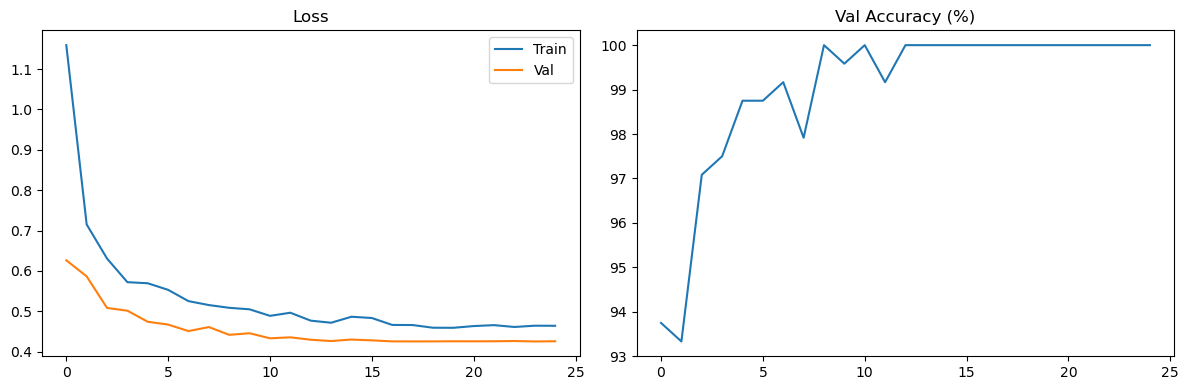

In [7]:
WEIGHTS_PATH = "efficientnet_rot_detector.pth"

def train_model(epochs=25):
    print(f"Training for {epochs} epochs...")
    train_losses, val_losses, val_accs = [], [], []
    best_val_acc = 0.0

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for batch in train_loader:
            inputs = batch["pixel_values"].to(device)
            targets = batch["label"].to(device)
            optimizer.zero_grad()
            loss = criterion(model(inputs), targets)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        avg_train = running_loss / len(train_loader)
        train_losses.append(avg_train)

        model.eval()
        val_loss, correct, total = 0.0, 0, 0
        with torch.no_grad():
            for batch in test_loader:
                inputs = batch["pixel_values"].to(device)
                targets = batch["label"].to(device)
                outputs = model(inputs)
                val_loss += criterion(outputs, targets).item()
                _, preds = torch.max(outputs, 1)
                correct += (preds == targets).sum().item()
                total += targets.size(0)

        avg_val = val_loss / len(test_loader)
        val_acc = correct / total * 100
        val_losses.append(avg_val)
        val_accs.append(val_acc)
        scheduler.step()

        print(f"Epoch {epoch+1:2d}/{epochs} | Train: {avg_train:.4f} | Val: {avg_val:.4f} | Acc: {val_acc:.1f}% | LR: {optimizer.param_groups[0]['lr']:.2e}")

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            torch.save({'model_state_dict': model.state_dict(), 'labels': labels, 'num_classes': num_classes, 'val_acc': val_acc}, WEIGHTS_PATH)
            print(f"  ✓ Best model saved ({val_acc:.1f}%)")

    print(f"\nBest val accuracy: {best_val_acc:.1f}%")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(train_losses, label='Train'); ax1.plot(val_losses, label='Val'); ax1.set_title('Loss'); ax1.legend()
    ax2.plot(val_accs); ax2.set_title('Val Accuracy (%)')
    plt.tight_layout(); plt.show()

train_model(epochs=25)

## 5. Inference Pipeline

### Internal rot:
`get_multi_crops()` generates 3 crops per detection: full box, center 60%, inner 40%.
The dark rotted core appears in the center crops even when the outer skin looks healthy.
Averaging probabilities across all 3 crops (`classify_crop_ensemble`) catches it.

### Heavy mold:
`check_mold_heuristic()` scans HSV pixel statistics before YOLO runs.
If >30% of pixels have low saturation (grey/ashy), it lowers YOLO's confidence threshold from 0.35 to 0.15
so severely discolored fruit (that no longer looks like a normal apple) is still detected.

In [8]:
def load_model_weights(path=WEIGHTS_PATH):
    if not os.path.exists(path):
        raise FileNotFoundError(f"No weights at {path}. Run train_model() first.")
    checkpoint = torch.load(path, map_location=device)
    model.load_state_dict(checkpoint['model_state_dict'])
    print(f"Loaded weights — best val acc: {checkpoint.get('val_acc', 0):.1f}%")


YOLO_TO_RESNET = {
    47: [labels.index('FreshApple'),  labels.index('RottenApple')]  if 'FreshApple'  in labels else None,
    46: [labels.index('FreshBanana'), labels.index('RottenBanana')] if 'FreshBanana' in labels else None,
    49: [labels.index('FreshOrange'), labels.index('RottenOrange')] if 'FreshOrange' in labels else None,
}
YOLO_TO_RESNET = {k: v for k, v in YOLO_TO_RESNET.items() if v is not None}
CONFIDENCE_THRESHOLD = 0.55


def get_multi_crops(img, x1, y1, x2, y2):
    """3 crops per detection: full box, center 60%, inner 40%.
    The center/inner crops expose internal rot that the full crop misses."""
    w_img, h_img = img.size
    pad = 15
    full = img.crop((max(0,x1-pad), max(0,y1-pad), min(w_img,x2+pad), min(h_img,y2+pad)))

    cx, cy = (x1+x2)//2, (y1+y2)//2
    bw, bh = x2-x1, y2-y1

    center = img.crop((max(0,cx-int(bw*0.3)), max(0,cy-int(bh*0.3)),
                       min(w_img,cx+int(bw*0.3)), min(h_img,cy+int(bh*0.3))))
    inner  = img.crop((max(0,cx-int(bw*0.2)), max(0,cy-int(bh*0.2)),
                       min(w_img,cx+int(bw*0.2)), min(h_img,cy+int(bh*0.2))))
    return [full, center, inner]


def classify_crop_ensemble(crops, allowed_indices):
    """Average softmax over all crops. Any crop showing rot pushes the score up."""
    all_probs = []
    for crop in crops:
        logits = model(preprocess(crop).unsqueeze(0).to(device))[0]
        all_probs.append(F.softmax(logits[allowed_indices], dim=0))
    avg = torch.stack(all_probs).mean(0)
    best = torch.argmax(avg).item()
    return labels[allowed_indices[best]], avg[best].item()


def check_mold_heuristic(img):
    """HSV pixel check: heavy mold = large fraction of low-saturation pixels.
    Returns (is_likely_mold, mold_pixel_ratio)."""
    hsv = np.array(img.resize((64, 64)).convert('HSV'), dtype=np.float32)
    S = hsv[:,:,1] / 255.0
    V = hsv[:,:,2] / 255.0
    mold_mask = (S < 0.25) & (V > 0.15) & (V < 0.75)  # Grey/ashy, not black or white
    ratio = mold_mask.sum() / mold_mask.size
    return ratio > 0.30, ratio


def smart_pipeline(image_path, conf_threshold=CONFIDENCE_THRESHOLD):
    img = Image.open(image_path).convert("RGB")
    model.eval()

    # Mold pre-check — adjust YOLO sensitivity before detection
    is_likely_mold, mold_ratio = check_mold_heuristic(img)
    yolo_conf = 0.15 if is_likely_mold else 0.35
    if is_likely_mold:
        print(f"⚠ Mold heuristic: {mold_ratio*100:.0f}% low-saturation pixels. Using low YOLO conf ({yolo_conf}).")

    results = yolo_model(image_path, conf=yolo_conf, verbose=False)

    fig, ax = plt.subplots(1, figsize=(10, 8))
    ax.imshow(img)
    detections_made = 0

    with torch.no_grad():
        for r in results:
            for box in r.boxes:
                yolo_cls = int(box.cls)
                if yolo_cls not in YOLO_TO_RESNET:
                    continue

                x1, y1, x2, y2 = map(int, box.xyxy[0])
                crops = get_multi_crops(img, x1, y1, x2, y2)
                label_text, conf = classify_crop_ensemble(crops, YOLO_TO_RESNET[yolo_cls])

                is_rotten = 'Rotten' in label_text
                color = 'red' if is_rotten else 'lime'
                style = 'solid' if conf >= conf_threshold else '--'
                box_color = color if conf >= conf_threshold else 'grey'
                display = f"{label_text} ({conf*100:.1f}%)" if conf >= conf_threshold else f"Uncertain ({conf*100:.1f}%)"

                ax.add_patch(patches.Rectangle((x1,y1), x2-x1, y2-y1, linewidth=3, edgecolor=box_color, facecolor='none', linestyle=style))
                ax.text(x1, y1-10, display, color='white', fontsize=12, bbox=dict(facecolor=box_color, alpha=0.85, pad=3))

                if conf >= conf_threshold:
                    detections_made += 1

        # Fallback: full-image classification
        if detections_made == 0:
            print("YOLO found no confident detections. Running full-image fallback...")
            logits = model(preprocess(img).unsqueeze(0).to(device))[0]
            probs = F.softmax(logits, dim=0)
            top_prob, top_idx = torch.max(probs, 0)
            label_text = labels[top_idx.item()]
            color = 'red' if 'Rotten' in label_text else 'lime'
            suffix = f" [mold heuristic: {mold_ratio*100:.0f}%]" if is_likely_mold else ""
            ax.set_title(f"Fallback: {label_text} ({top_prob.item()*100:.1f}%){suffix}", fontsize=13, color=color)

    plt.axis('off')
    plt.tight_layout()
    plt.show()


load_model_weights()

Loaded weights — best val acc: 100.0%


## 6. Test on Images


Processing: rotton_apple.webp
YOLO found no confident detections. Running full-image fallback...


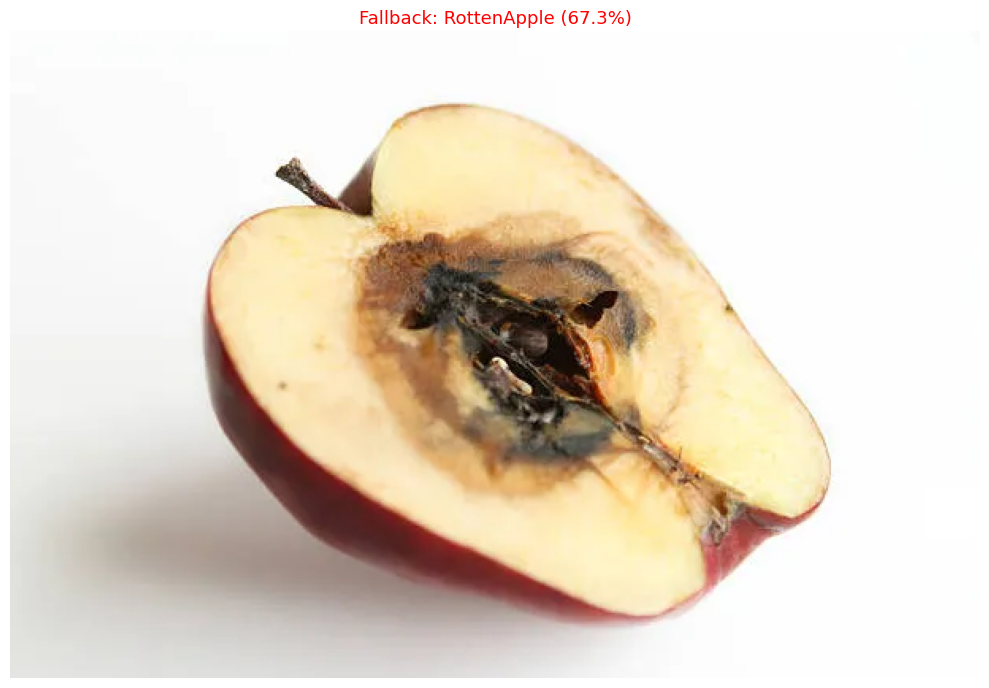


Processing: rotten_brown.webp
⚠ Mold heuristic: 39% low-saturation pixels. Using low YOLO conf (0.15).
YOLO found no confident detections. Running full-image fallback...


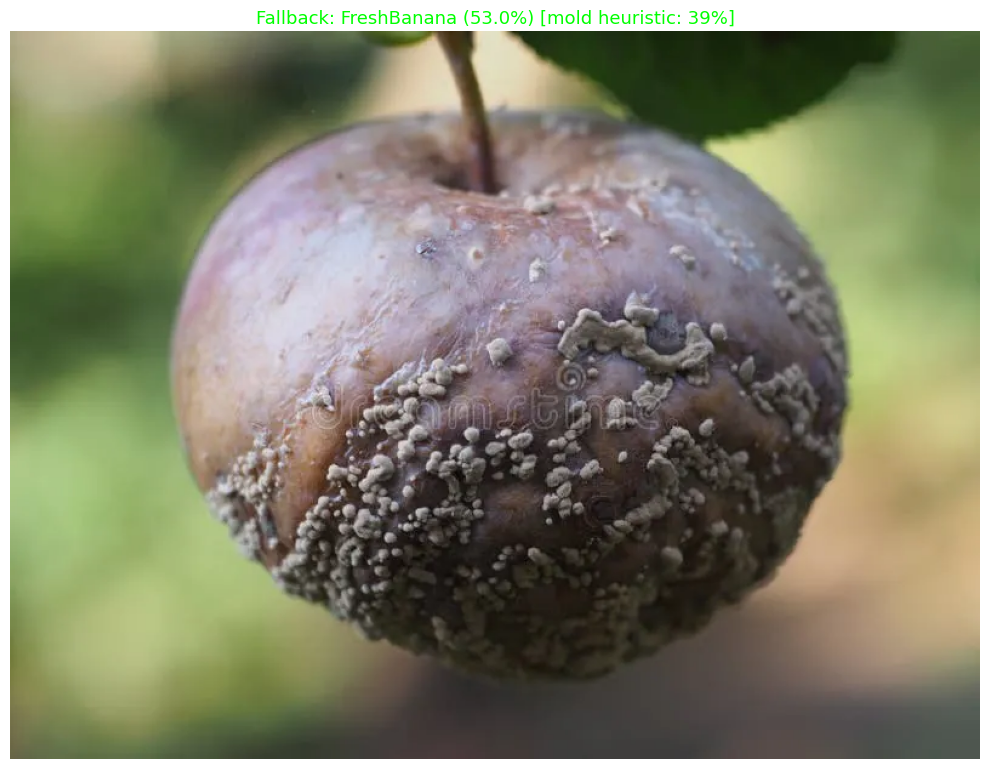

In [9]:
test_images = [
    "rotton_apple.webp",   # Internal rot
    "rotten_brown.webp",   # Heavy mold
]

for img_path in test_images:
    if os.path.exists(img_path):
        print(f"\n{'='*50}\nProcessing: {img_path}")
        smart_pipeline(img_path)
    else:
        print(f"Not found: {img_path}")

## 7. Evaluation

Evaluating on test set...

--- Classification Report ---
              precision    recall  f1-score   support

  FreshApple       1.00      1.00      1.00        51
 RottenApple       1.00      1.00      1.00        49
 FreshBanana       1.00      1.00      1.00        35
RottenBanana       1.00      1.00      1.00        40
 FreshOrange       1.00      1.00      1.00        31
RottenOrange       1.00      1.00      1.00        34

    accuracy                           1.00       240
   macro avg       1.00      1.00      1.00       240
weighted avg       1.00      1.00      1.00       240



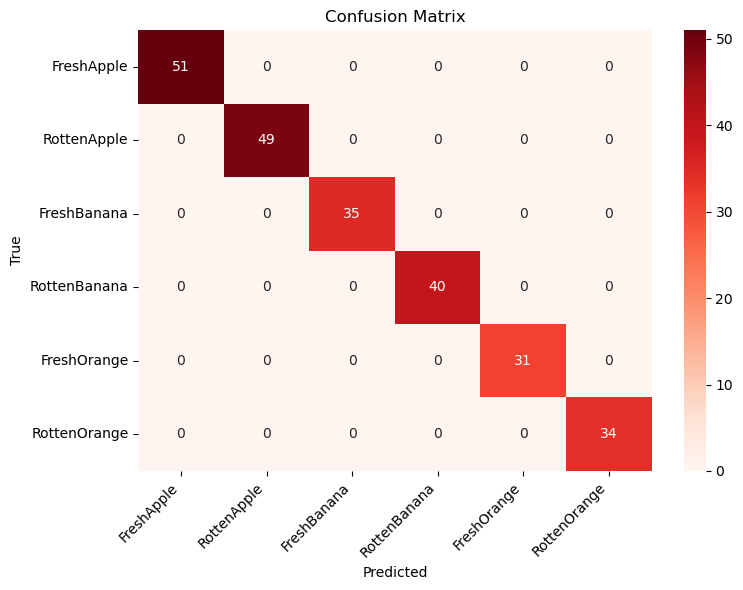

In [10]:
def evaluate_model(loader):
    print("Evaluating on test set...")
    model.eval()
    all_preds, all_labels_list = [], []
    with torch.no_grad():
        for batch in loader:
            inputs = batch["pixel_values"].to(device)
            targets = batch["label"].to(device)
            _, preds = torch.max(model(inputs), 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels_list.extend(targets.cpu().numpy())

    print("\n--- Classification Report ---")
    print(classification_report(all_labels_list, all_preds, target_names=labels))

    cm = confusion_matrix(all_labels_list, all_preds)
    plt.figure(figsize=(max(8, num_classes), max(6, num_classes-2)))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap="Reds")
    plt.title("Confusion Matrix")
    plt.xlabel("Predicted"); plt.ylabel("True")
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout(); plt.show()

evaluate_model(test_loader)